## Objectives

After completing this lab you will be able to:

* Use scikit-learn's k-means clustering to cluster data
* Apply k-means clustering on a real world data for Customer segmentation

we will be making random clusters of points by using the `make_blobs` class. The `make_blobs` class can take in many inputs, but we will be using these specific ones. <br> <br>
<b> <u> Input </u> </b>
<ul>
    <li> <b>n_samples</b>: The total number of points equally divided among clusters. </li>
    <ul> <li> Value will be: 5000 </li> </ul>
    <li> <b> centres </b>: The number of centres to generate, or the fixed centre locations. </li>
    <ul> <li> Value will be: [[4, 4], [-2, -1], [2, -3],[1,1]] </li> </ul>
    <li> <b>cluster_std</b>: The standard deviation of the clusters. </li>
    <ul> <li> Value will be: 0.9 </li> </ul>
</ul>
<br>
<b> <u> Output </u> </b>
<ul>
    <li> <b>X</b>: Array of shape [n_samples, n_features]. (Feature Matrix)</li>
    <ul> <li> The generated samples. </li> </ul> 
    <li> <b>y</b>: Array of shape [n_samples]. (Response Vector)</li>
    <ul> <li> The integer labels for cluster membership of each sample. </li> </ul>
</ul>

In [1]:
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs 
import plotly.graph_objects as go

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

<h1 id="random_generated_dataset">K-Means on a synthetic data set</h1>

Let's create our own dataset for this lab!


we need to set a random seed. Use <b>numpy's random.seed()</b> function, where the seed will be set to <b>0</b>.

In [ ]:
np.random.seed(0)

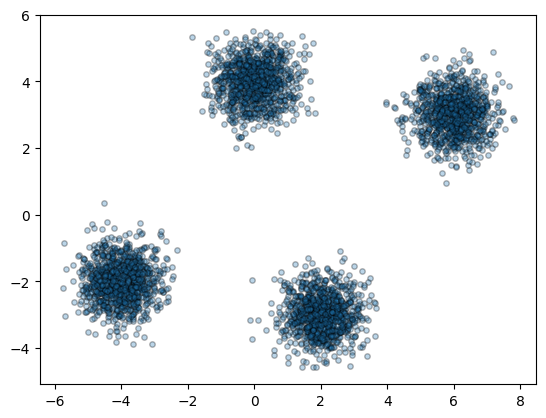

In [46]:
X, y = make_blobs(n_samples=4000, centers=[[6,3], [-4, -2], [2, -3], [0, 4]], cluster_std=0.6)
plt.scatter(X[:, 0], X[:, 1], marker='.',alpha=0.3,ec='k',s=60)

In [47]:
model = KMeans(init = "k-means++", n_clusters = 4, n_init = 12)
model.fit(X)

,n_clusters,4
,init,'k-means++'
,n_init,12
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [51]:
k_means_labels = model.labels_
print(k_means_labels)

k_means_cluster_centers = model.cluster_centers_
print(k_means_cluster_centers)

[2 0 1 ... 2 2 1]
[[-4.02493336 -2.01219144]
 [ 5.99700109  3.01265131]
 [ 0.01002089  3.97869084]
 [ 2.02144686 -2.99606029]]


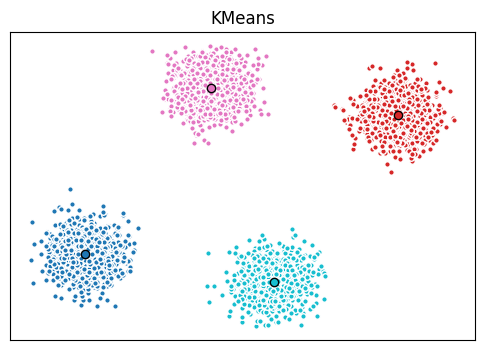

In [58]:
# Initialize the plot with the specified dimensions.
fig = plt.figure(figsize=(6, 4))

# Colors uses a color map, which will produce an array of colors based on
# the number of labels there are. We use set(k_means_labels) to get the
# unique labels.
colors = plt.cm.tab10(np.linspace(0, 1, len(set(k_means_labels))))

# Create a plot
ax = fig.add_subplot(1, 1, 1)

# For loop that plots the data points and centroids.
# k will range from 0-3, which will match the possible clusters that each
# data point is in.
for k, col in zip(range(len([[6, 3], [-4, -2], [2, -3], [0, 4]])), colors):

    # Create a list of all data points, where the data points that are 
    # in the cluster (ex. cluster 0) are labeled as true, else they are
    # labeled as false.
    my_members = (k_means_labels == k)

    # Define the centroid, or cluster center.
    cluster_center = k_means_cluster_centers[k]

    # Plots the datapoints with color col.
    ax.plot(X[my_members, 0], X[my_members, 1], 'w', markerfacecolor=col, marker='.',ms=8)

    # Plots the centroids with specified color, but with a darker outline
    ax.plot(cluster_center[0], cluster_center[1], 'o', markerfacecolor=col,  markeredgecolor='k', markersize=6)

# Title of the plot
ax.set_title('KMeans')

# Remove x-axis ticks
ax.set_xticks(())

# Remove y-axis ticks
ax.set_yticks(())

# Show the plot
plt.show()
